In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import psutil

!pip install ftfy pyarrow openpyxl


FIG_DIR = "cancer pain eda visualisations"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches="tight")


**Select Desired Columns**

In [7]:


all_text = []

cols_wanted = [
    "score", "controversiality",
    "body",
    "author", "id", "link_id", "parent_id",
    "created_utc",
    "title", "selftext", "author_fullname"
]



In [8]:
import os

for file in os.listdir("cancer pain data"):
    size_mb = os.path.getsize(f"cancer pain data/{file}") / 1024**2
    print(f"{file}: {size_mb:.1f} MB")

advancedcancer_comments.ndjson: 0.0 MB
advancedcancer_submissions.ndjson: 0.1 MB
bladdercancer_comments.ndjson: 45.1 MB
bladdercancer_submissions.ndjson: 8.3 MB
bloodcancer_comments.ndjson: 0.0 MB
bloodcancer_submissions.ndjson: 0.1 MB
braintumor_comments.ndjson: 41.1 MB
braintumor_submissions.ndjson: 10.3 MB
breastcancer_comments.ndjson: 1573.8 MB
breastcancer_submissions.ndjson: 177.4 MB
cancerpatients_comments.ndjson: 2.9 MB
cancerpatients_submissions.ndjson: 1.2 MB
cancerteens_comments.ndjson: 0.4 MB
cancerteens_submissions.ndjson: 0.2 MB
cancer_comments.ndjson: 876.3 MB
cancer_submissions.ndjson: 217.8 MB
cervicalcancer_comments.ndjson: 62.5 MB
cervicalcancer_submissions.ndjson: 12.6 MB
coloncancer_comments.ndjson: 220.8 MB
coloncancer_submissions.ndjson: 35.9 MB
endometrialcancer_comments.ndjson: 33.5 MB
endometrialcancer_submissions.ndjson: 4.8 MB
headandneckcancer_comments.ndjson: 58.7 MB
headandneckcancer_submissions.ndjson: 9.5 MB
kidneycancer_comments.ndjson: 43.2 MB
kidneyc

**Read in RAW Data**

In [9]:

import pyarrow as pa
import pyarrow.parquet as pq

output_file = "cancer_pain_rawdata.parquet"

int_cols = ["score", "controversiality", "created_utc"]
str_cols = [c for c in cols_wanted if c not in int_cols] + ["source_file"]

schema = pa.schema(
    [(c, pa.int64()) for c in int_cols] + [(c, pa.string()) for c in str_cols]
)

writer = pq.ParquetWriter(output_file, schema, compression="snappy")

try:
    for file in os.listdir("cancer pain data"):
        path = f"cancer pain data/{file}"

        for chunk in pd.read_json(path, lines=True, chunksize=100_000, dtype=False):

            for col in cols_wanted:
                if col not in chunk.columns:
                    chunk[col] = None

            temp = chunk[cols_wanted].copy()
            temp["source_file"] = file

            for c in int_cols:
                temp[c] = pd.to_numeric(temp[c], errors="coerce").astype("Int64")
            for c in str_cols:
                temp[c] = temp[c].astype("string")

            table = pa.Table.from_pandas(temp[schema.names], schema=schema, preserve_index=False)
            writer.write_table(table)
finally:
    writer.close()

print(os.path.getsize(output_file)/1024**3, "GB")


0.47559518460184336 GB


In [10]:
# Load the raw data file
text_df = pd.read_parquet("cancer_pain_rawdata.parquet")


***DATA CLEANING***

In [11]:
#Aggregated text data

text_df["text"] = (
    text_df["body"].fillna("")
    + text_df["title"].fillna("")
    + text_df["selftext"].fillna("")
)

text_df["text_length"] = text_df["text"].str.len()

In [12]:
# Remove rows without textual data

rows_before_text_clean = len(text_df)

text_df = text_df[
    text_df["text"].notna()
    & (text_df["text"] != "[deleted]")
    & (text_df["text"] != "[removed]")
]

rows_after_text_clean = len(text_df)

In [13]:
from ftfy import fix_text

text_df['body'] = text_df['body'].apply(
    lambda x: fix_text(x) if isinstance(x, str) else x
)

In [14]:
text_df.info()

<class 'pandas.DataFrame'>
Index: 2123291 entries, 0 to 2169644
Data columns (total 14 columns):
 #   Column            Dtype  
---  ------            -----  
 0   score             int64  
 1   controversiality  float64
 2   created_utc       int64  
 3   body              str    
 4   author            str    
 5   id                str    
 6   link_id           str    
 7   parent_id         str    
 8   title             str    
 9   selftext          str    
 10  author_fullname   str    
 11  source_file       str    
 12  text              str    
 13  text_length       int64  
dtypes: float64(1), int64(3), str(10)
memory usage: 1.8 GB


In [15]:
#convert utc to calendar time and date

text_df["created_datetime"] = pd.to_datetime(
    text_df["created_utc"],
    unit="s",
    errors="coerce"
)

In [16]:
# Extract age + gender
pattern = r'(?i)(?:^|\b|\(|\[)(1[3-9]|[2-8]\d|90)\s*[/\-]?\s*([mf])(?:\b|\)|\])'

extracted = text_df["body"].str.extract(pattern)
extracted.columns = ["age", "gender"]

text_df["age"] = pd.to_numeric(extracted["age"], errors="coerce")
text_df["gender"] = extracted["gender"].str.upper()


# Extract context around age/gender match
def extract_age_gender_context(text):
    if pd.isna(text):
        return None
    
    match = re.search(pattern, text)
    
    if not match:
        return None
    
    start = max(match.start() - 50, 0)
    end = min(match.end() + 50, len(text))
    
    return text[start:end]

text_df["age_gender_context"] = text_df["body"].apply(extract_age_gender_context)



text_df.loc[
    text_df["age"].notna(),
    ["body", "age", "gender", "age_gender_context"]
].head(20)

,body,age,gender,age_gender_context
122,"I'm in a bit of a similar situation. 38M, neve...",38.0,M,"I'm in a bit of a similar situation. 38M, neve..."
138,34M here. One year cancer free after stage thr...,34.0,M,34M here. One year cancer free after stage thr...
181,"Hello,\nI am 41F and I am worried I also have ...",41.0,F,"Hello,\nI am 41F and I am worried I also have ..."
192,"Hi Michael, 41 m here too. I was diagnosed wit...",41.0,M,"Hi Michael, 41 m here too. I was diagnosed wit..."
209,As far as recovery time and what she needs aft...,30.0,F,"obility, and what urinary diversion she gets. ..."
215,"My father 64M, had radical cystectomy on 16 Au...",64.0,M,"My father 64M, had radical cystectomy on 16 Au..."
216,Definetly check out Urostomy Awareness on Face...,40.0,F,h is still very much a huge focus of my day. I...
234,No one can give you the answers for survival w...,64.0,M,ive you some idea about BC. \nJAN 2019 - my fa...
239,You got this dude! 34M here. TURBT in Mar 2020...,34.0,M,You got this dude! 34M here. TURBT in Mar 2020...
294,That sounds normal to me. TURBT made my urine ...,34.0,M,First pee of the day is always gonna be the wo...


In [17]:
#Extract Weekday and Hour from time

text_df["created_datetime"] = pd.to_datetime(text_df["created_utc"], unit="s", errors="coerce")

text_df["weekday"] = text_df["created_datetime"].dt.day_name()
text_df["hour"] = text_df["created_datetime"].dt.hour

In [18]:
# Remove moderator, bot, and deleted accounts

text_df = text_df[
    ~text_df["author"].str.contains(
        r"AutoModerator|ModTeam|Moderator",
        case=False,
        na=False
    )
]

text_df = text_df[text_df["author"] != "[deleted]"]



print(f"Remaining rows: {len(text_df):,}")

Remaining rows: 2,048,972


***DATA EXPLORATION***

In [19]:
#Number of Posts / Comments and Users

n_posts = len(text_df)
n_users = text_df["author"].nunique()

print(f"Posts/comments: {n_posts:,}")
print(f"Unique users: {n_users:,}")

Posts/comments: 2,048,972
Unique users: 169,549


In [20]:
print(f"Removed rows due to no text: {rows_before_text_clean - rows_after_text_clean:,}")

Removed rows due to no text: 46,354


In [21]:
# Rows that were removed for moderators, check validity

removed_rows = text_df[
    text_df["author"].str.contains(
        r"AutoModerator|ModTeam|Moderator",
        case=False,
        na=False
    )
    | (text_df["author"] == "[deleted]")
]

print(f"Removed rows: {len(removed_rows):,}")
removed_rows.head(20)

removed_rows.groupby("author").agg(
    contributions=("author", "size"),
    total_score=("score", "sum"),
    first_activity=("created_datetime", "min"),
    last_activity=("created_datetime", "max")
).sort_values("contributions", ascending=False)

Removed rows: 0


,contributions,total_score,first_activity,last_activity
author,,,,


In [22]:
# Rows removed for missing/deleted text

print(f"Removed rows: {rows_before_text_clean - rows_after_text_clean:,}")

removed_text_rows = text_df[
    text_df["text"].isna()
    | (text_df["text"] == "[deleted]")
    | (text_df["text"] == "[removed]")
]
removed_text_rows.head(20)

removed_text_rows["text"].value_counts(dropna=False)

Removed rows: 46,354


Series([], Name: count, dtype: int64)

In [23]:
# Count total contributions (posts + comments) per user

contribution_summary = (
    text_df
    .groupby("author")
    .agg(
        total_contributions=("author", "size"),
        total_score=("score", "sum"),
        avg_score=("score", "mean"),
        first_activity=("created_datetime", "min"),
        last_activity=("created_datetime", "max")
    )
    .sort_values("total_contributions", ascending=False)
)

contribution_summary.head(20)

,total_contributions,total_score,avg_score,first_activity,last_activity
author,,,,,
Diligent-Activity-70,6051,28443,4.700545,2022-04-29 15:24:05,2025-12-30 15:26:00
Lower-Variation-5374,4543,16282,3.583975,2022-11-13 20:18:46,2025-12-31 21:20:52
AnkuSnoo,4231,17968,4.246750,2023-10-13 16:05:02,2025-12-31 23:23:34
Kai12223,4051,14424,3.560602,2022-10-29 18:08:13,2025-12-31 23:00:10
WesternTumbleweeds,3930,11509,2.928499,2021-02-22 18:28:21,2025-12-30 14:23:31
Delouest,3888,21533,5.538323,2020-01-01 22:32:09,2025-12-31 23:50:54
LeaString,3812,12995,3.408972,2023-02-27 07:37:24,2025-12-31 20:24:54
EtonRd,3549,19221,5.415892,2022-02-12 18:39:03,2025-12-28 18:57:48
AveryElle87,3387,12676,3.742545,2022-07-31 17:57:55,2025-12-31 13:09:20


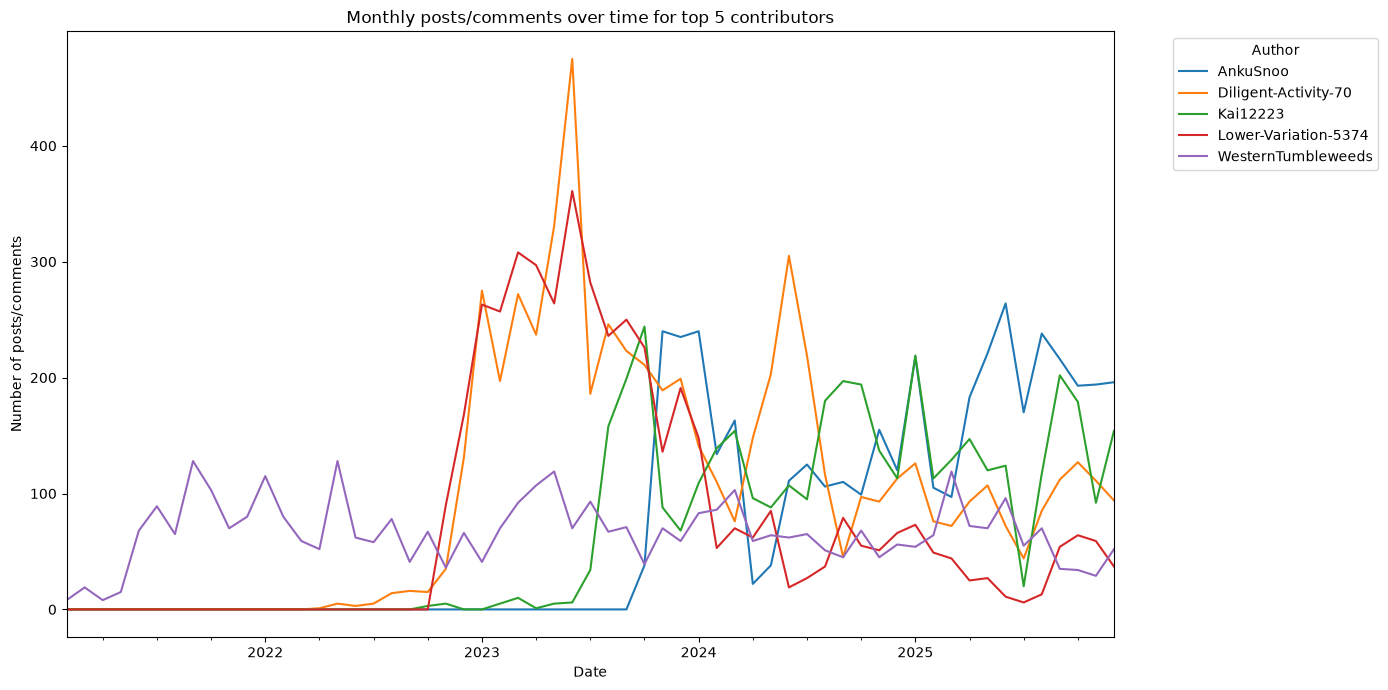

In [24]:
# Plot activity over time for the most active users

top_users = contribution_summary.head(5).index

top_user_activity = (
    text_df[text_df["author"].isin(top_users)]
    .set_index("created_datetime")
    .groupby("author")
    .resample("ME")
    .size()
    .reset_index(name="n_contributions")
)

activity_pivot = top_user_activity.pivot(
    index="created_datetime",
    columns="author",
    values="n_contributions"
).fillna(0)

activity_pivot.plot(figsize=(14, 7))

plt.title("Monthly posts/comments over time for top 5 contributors")
plt.xlabel("Date")
plt.ylabel("Number of posts/comments")
plt.legend(title="Author", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_fig("top_user_trajectories.png")
plt.show()

In [25]:
# Add posting activity duration and rank users

contribution_summary["first_activity"] = pd.to_datetime(contribution_summary["first_activity"])
contribution_summary["last_activity"] = pd.to_datetime(contribution_summary["last_activity"])

contribution_summary["activity_duration_days"] = (
    contribution_summary["last_activity"] - contribution_summary["first_activity"]
).dt.days

contribution_summary["activity_rank"] = (
    contribution_summary["activity_duration_days"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

contribution_summary.sort_values(
    "activity_duration_days",
    ascending=False
).head(20)

,total_contributions,total_score,avg_score,first_activity,last_activity,activity_duration_days,activity_rank
author,,,,,,,
Delouest,3888,21533,5.538323,2020-01-01 22:32:09,2025-12-31 23:50:54,2191,1
Janissa11,576,1013,1.758681,2020-01-02 02:23:48,2025-12-30 00:48:24,2188,2
Blendedtribes,217,762,3.511521,2020-01-02 15:13:15,2025-12-28 17:31:48,2187,3
Hop-a-lung,192,1008,5.250000,2020-01-07 02:40:11,2025-12-31 00:01:23,2184,4
KgoodMIL,1154,3981,3.449740,2020-01-05 16:51:23,2025-12-29 09:09:33,2184,4
gregnorz,1266,3973,3.138231,2020-01-05 23:51:55,2025-12-29 19:36:29,2184,4
Litarider,2729,11720,4.294613,2020-01-08 01:54:12,2025-12-31 01:55:30,2184,4
aje1121,343,1354,3.947522,2020-01-05 01:34:40,2025-12-28 02:23:55,2184,4
Rekd44,5,13,2.600000,2020-01-05 15:40:17,2025-12-27 23:52:16,2183,5


In [26]:
# Proportion of users posting for 1 year or more

n_users = len(contribution_summary)

n_year_plus = (
    contribution_summary["activity_duration_days"] >= 365
).sum()

print(f"{n_year_plus:,} users ({n_year_plus / n_users:.2%}) posted for 1 year or more")

18,693 users (11.03%) posted for 1 year or more


In [27]:
#Propotion of posters with 5+ comments

n_authors = len(contribution_summary)
n_10plus = (contribution_summary["total_contributions"] >= 5).sum()

print(f"{n_10plus} authors ({n_10plus/n_authors:.1%}) have 5+ posts/comments")

48876 authors (28.8%) have 5+ posts/comments


In [28]:
text_df.groupby("author").size()

author
-------o                 4
-----Galaxy-----         2
----annie----           15
---__---__---_           1
--13--13                 1
                        ..
zztopfila                2
zzxxzzxxzzxxzzxxzzxx     1
zzz099                   5
zzzbummer                1
zzzzlllll13             24
Length: 169549, dtype: int64

In [29]:
#Random Sampling to assess accuracy

sample = text_df[text_df["age"].notna()][
    ["body", "age", "gender", "age_gender_context"]
].sample(100, random_state=42)

sample.sort_values(by = 'age')

,body,age,gender,age_gender_context
1873803,One son then 19 M gave stem cells to other son...,19.0,M,One son then 19 M gave stem cells to other son...
1271810,"Hi there, I'm 19M UK, cancer at 17 but treatme...",19.0,M,"Hi there, I'm 19M UK, cancer at 17 but treatme..."
1871496,As long as you can door dash or uber eats to t...,19.0,M,where I went. But you will lose some weight. ...
1830951,I (19M) was diagnosed at 17 with T-ALL. My tre...,19.0,M,I (19M) was diagnosed at 17 with T-ALL. My tre...
1690252,20 F [ BLOOD IN STOOL FOR 5 DAYS ]\n My doctor...,20.0,F,20 F [ BLOOD IN STOOL FOR 5 DAYS ]\n My doctor...
...,...,...,...,...
1720391,"Just checking ""Do they need a Carer?"" I am 67f...",67.0,F,"Just checking ""Do they need a Carer?"" I am 67f..."
1434812,Thank you for this post and I'm so sorry that ...,75.0,M,tal health problems associated with treatment....
1627528,That's a fuck-ton of chemo. \n\n- Marijuana fo...,75.0,F,read thermometer to make sure beverages are ab...
2048890,Plastic surgeons are artists. My mom's (77F) ...,77.0,F,Plastic surgeons are artists. My mom's (77F) ...


In [30]:
text_df['body'].loc[1409305]

"Still in treatment for stage 3 (75f) and not feeling physically great but planning on maybe cruise this year and trip with the dogs to Colorado.\xa0 Next year build a new house.\xa0 Don't laugh.\xa0 Grew up watching Bonanza and want to replicate the house on the Ponderosa.\xa0 Cancer makes you put your perspectives in order.\xa0 Also finish up some of my writings and publish a book of my poems. Too much?\xa0"

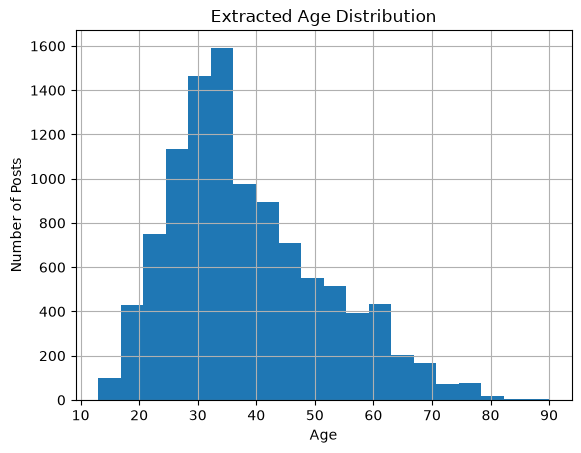

In [31]:
#Age distribution

text_df["age"].hist(bins=20)

plt.title("Extracted Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Posts")
save_fig("age_distribution.png")
plt.show()

In [32]:
#Age descriptions

text_df['age'].describe()

count    10493.000000
mean        38.562280
std         13.184027
min         13.000000
25%         29.000000
50%         36.000000
75%         46.000000
max         90.000000
Name: age, dtype: float64

In [33]:
#Check older ages

text_df[text_df["age"] >= 70][
    ["body", "age", "gender", "age_gender_context"]
].head(30)

,body,age,gender,age_gender_context
4697,My mom is 81F muscle invasive with spread to l...,81.0,F,My mom is 81F muscle invasive with spread to l...
12671,my dad (70 m) just had his bladdar removed and...,70.0,M,my dad (70 m) just had his bladdar removed and...
13979,"78f bc patient, locally advanced metastasis wi...",78.0,F,"78f bc patient, locally advanced metastasis wi..."
14592,"My experience, (70m) I had a TURBT 7 years ago...",70.0,M,"My experience, (70m) I had a TURBT 7 years ago..."
15907,Yeah. I've had bladder problems for over 10 ye...,83.0,M,ve also lost 10kg during the past 4 months (I'...
16953,"71m, Had robotic RC with neobladder completed ...",71.0,M,"71m, Had robotic RC with neobladder completed ..."
18663,"71F, went from stellar blood work, vitals to s...",71.0,F,"71F, went from stellar blood work, vitals to s..."
20474,My mom (76F) is stage 3 urothelial carcinoma M...,76.0,F,My mom (76F) is stage 3 urothelial carcinoma M...
20475,Chemo is going to be pushed as the mainline tr...,76.0,F,cover with only so many hands so to speak. My ...
20476,"With my mom (76F, stage 3 urothelial carcinoma...",76.0,F,"With my mom (76F, stage 3 urothelial carcinoma..."


In [34]:
#Posts per user

user_counts = text_df.groupby("author").size()

print(user_counts.describe())

print('Median: ',user_counts.median())

count    169549.000000
mean         12.084837
std          66.172725
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max        6051.000000
dtype: float64
Median:  2.0


In [35]:
print("Users with 10 or more posts: ", (user_counts >= 10).sum())


Users with 10 or more posts:  28235


In [36]:
#Number of Users with more than 5 Posts

print("Users with 5 or more posts: ", (user_counts >= 5).sum())


Users with 5 or more posts:  48876


In [37]:
#Number of Users with more than 2 posts

print("Users with 2 or more posts: ", (user_counts >= 2).sum())

Users with 2 or more posts:  98574


In [38]:
#Data timeline

print('Data starts: ', text_df["created_datetime"].min())
print('Data ends: ', text_df["created_datetime"].max())

Data starts:  2020-01-01 00:01:03
Data ends:  2025-12-31 23:59:45


hour
0     113166
1     113656
2     108352
3      93165
4      74069
5      57453
6      45445
7      37414
8      33942
9      34016
10     40067
11     54033
12     69864
13     85774
14     98712
15    106790
16    108659
17    110673
18    110092
19    109632
20    112492
21    111320
22    108843
23    111343
dtype: int64


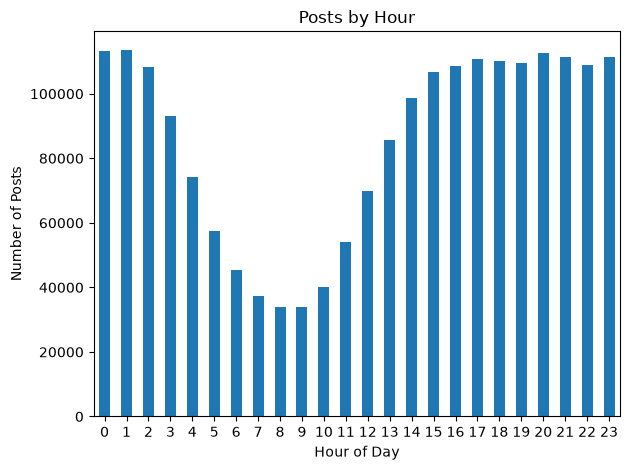

In [39]:
#Posts by hour

text_df["hour"] = text_df["created_datetime"].dt.hour

print(text_df.groupby("hour").size())

posts_by_hour = text_df.groupby("hour").size()

posts_by_hour.plot(kind="bar")

plt.title("Posts by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
save_fig("posts_by_hour.png")
plt.show()

weekday
Friday       301032
Monday       285667
Saturday     276459
Sunday       265775
Thursday     307762
Tuesday      302091
Wednesday    310186
dtype: int64


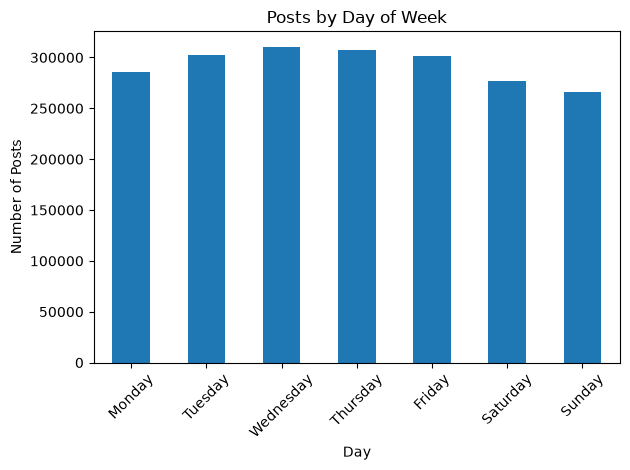

In [40]:
#Posts by day

text_df["weekday"] = text_df["created_datetime"].dt.day_name()

print(text_df.groupby("weekday").size())


weekday_counts = (
    text_df.groupby("weekday")
    .size()
    .reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday",
         "Friday", "Saturday", "Sunday"]
    )
)


# Bar chart
weekday_counts.plot(kind="bar")

plt.title("Posts by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("posts_by_weekday.png")
plt.show()

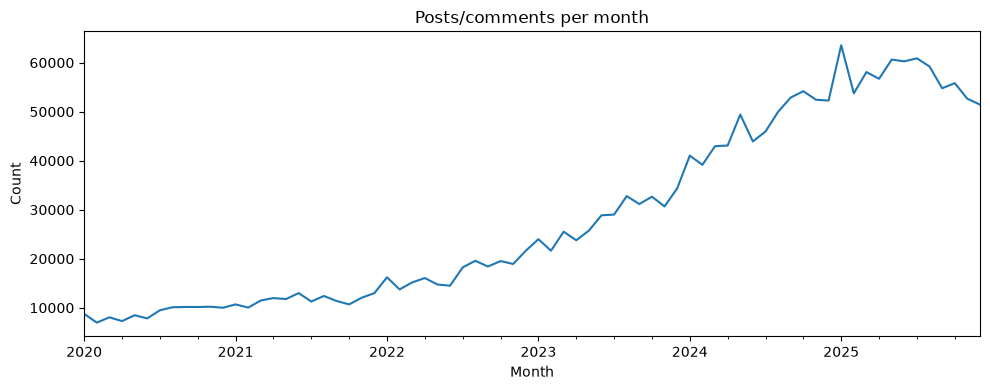

In [41]:
#posts by month

monthly_posts = (
    text_df
    .set_index("created_datetime")
    .resample("ME")
    .size()
)

monthly_posts.plot(
    kind="line",
    figsize=(10, 4),
    title="Posts/comments per month",
    xlabel="Month",
    ylabel="Count"
)

plt.tight_layout()
save_fig("posts_per_month.png")
plt.show()


In [42]:
#Score overview

print(text_df["score"].describe())
print('Median: ', text_df['score'].median())

count    2.048972e+06
mean     3.490067e+00
std      9.404801e+00
min     -1.420000e+02
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      1.777000e+03
Name: score, dtype: float64
Median:  2.0


In [43]:
#Highest rated posts

text_df.nlargest(10, "score")

,score,controversiality,created_utc,body,author,id,link_id,parent_id,title,selftext,author_fullname,source_file,text,text_length,created_datetime,age,gender,age_gender_context,weekday,hour
1569970,1777,NaN,1764843650,NaN,SadAnimator1354,1pdwis4,NaN,NaN,u/CancerSubscription is no longer with us,[I am not his friend. I am someone who used to...,t2_tvyshxtez,cancer_submissions.ndjson,u/CancerSubscription is no longer with us[I am...,6303,2025-12-04 10:20:50,NaN,NaN,NaN,Thursday,10
1562126,1620,NaN,1747441458,NaN,sweetiepie0812,1kog3ib,NaN,NaN,RIP Chris my autistic brother,"A little around 3 months ago, I posted my brot...",t2_w3u3yz1w,cancer_submissions.ndjson,RIP Chris my autistic brotherA little around 3...,2264,2025-05-17 00:24:18,NaN,NaN,NaN,Saturday,0
1564238,1058,NaN,1752503638,NaN,OkBumblebee1479,1lzo0fq,NaN,NaN,They said I wouldn’t live past 2 years—yesterd...,"At 21, I was diagnosed with peritoneal mesothe...",t2_1c1ws2hjr4,cancer_submissions.ndjson,They said I wouldn’t live past 2 years—yesterd...,810,2025-07-14 14:33:58,NaN,NaN,NaN,Monday,14
1558970,1040,NaN,1740158033,NaN,sweetiepie0812,1iuw1ri,NaN,NaN,my autistic brothers journey,I just wanted to come on here and share this p...,t2_w3u3yz1w,cancer_submissions.ndjson,my autistic brothers journeyI just wanted to c...,1736,2025-02-21 17:13:53,NaN,NaN,NaN,Friday,17
970040,993,NaN,1748625767,NaN,not_today_cancer,1kza0ud,NaN,NaN,Resignation Announcement,"Hi everyone,\n\nThe last five years of serving...",t2_3ywhc12q,breastcancer_submissions.ndjson,"Resignation AnnouncementHi everyone,\n\nThe la...",743,2025-05-30 17:22:47,NaN,NaN,NaN,Friday,17
1551260,975,NaN,1722132898,NaN,SpacelessMinds,1edwvsu,NaN,NaN,Diagnosed with stage 4 lung cancer last week. ...,,t2_8v82oc5c,cancer_submissions.ndjson,Diagnosed with stage 4 lung cancer last week. ...,81,2024-07-28 02:14:58,NaN,NaN,NaN,Sunday,2
1559743,920,NaN,1741924337,NaN,Ok_Damage7153,1jav5ps,NaN,NaN,Cancer Free!!,"Hi everyone, I've been reading through this su...",t2_tfwarhkds,cancer_submissions.ndjson,"Cancer Free!!Hi everyone, I've been reading th...",829,2025-03-14 03:52:17,NaN,NaN,NaN,Friday,3
1558471,887,NaN,1739120892,NaN,Active_Fish_6202,1iljhxl,NaN,NaN,Chemo in style. Still living life while midway...,,t2_vct3pysq,cancer_submissions.ndjson,Chemo in style. Still living life while midway...,148,2025-02-09 17:08:12,NaN,NaN,NaN,Sunday,17
1556317,860,NaN,1734232553,NaN,Imstayinganonymou5,1hejon5,NaN,NaN,Lost The Battle,Lost The Battle\n\nI can’t find my Uncles Redd...,t2_s5ifiwij,cancer_submissions.ndjson,Lost The BattleLost The Battle\n\nI can’t find...,741,2024-12-15 03:15:53,NaN,NaN,NaN,Sunday,3
935913,759,NaN,1667738418,NaN,Lulilu90,ynowi8,NaN,NaN,I need advice,Maybe trigger warning\nWhen you got your treat...,t2_tm1rm9kl,breastcancer_submissions.ndjson,I need adviceMaybe trigger warning\nWhen you g...,480,2022-11-06 12:40:18,NaN,NaN,NaN,Sunday,12


In [44]:
#Text overview

print(text_df["text_length"].describe())
print('Median: ', text_df['text_length'].median())

count    2.048972e+06
mean     3.416296e+02
std      4.478641e+02
min      0.000000e+00
25%      8.400000e+01
50%      2.030000e+02
75%      4.300000e+02
max      3.682100e+04
Name: text_length, dtype: float64
Median:  203.0


In [45]:
#How many replies to comments we have

text_df["parent_id"].notna().mean()

np.float64(0.9084130969090841)

In [46]:
#Comments vs Posts split

print("Comments: ",text_df["body"].notna().sum())
print("Posts: ",text_df["title"].notna().sum())

Comments:  1861313
Posts:  187659


In [47]:
text_df = text_df[text_df['text'] != '[deleted]']
(text_df['text'] == '[deleted]').sum()


np.int64(0)

**Export to Parquet**

In [48]:

text_df.to_parquet("CancerPainData.parquet", index=False)


**Create Sample for Annotating**

In [49]:
# Randomly sample 250 rows with at least 5 words and 20 characters

text_col = "text"

eligible_df = text_df[
    text_df[text_col].notna()
    & (text_df[text_col].astype(str).str.split().str.len() >= 5)
    & (text_df[text_col].astype(str).str.len() >= 20)
].copy()

sample_250 = eligible_df.sample(
    n=250,
    random_state=42
).copy()

annotation_cols = [
    "sensory",
    "emotional",
    "behavioural",
    "cognitive"
]

for col in annotation_cols:
    sample_250[col] = ""

annot_file = "cancerannotation_sample_250.csv"
if os.path.exists(annot_file):
    print(f"{annot_file} already exists - not overwriting (delete it first to regenerate)")
else:
    sample_250.to_csv(annot_file, index=False, encoding="utf-8-sig")

print(f"Eligible rows: {len(eligible_df)}")
print(f"Sampled rows: {len(sample_250)}")

sample_250.head()

Eligible rows: 1908460
Sampled rows: 250


,score,controversiality,created_utc,body,author,id,link_id,parent_id,title,selftext,...,created_datetime,age,gender,age_gender_context,weekday,hour,sensory,emotional,behavioural,cognitive
802275,1,0.0,1755472506,The links too… thank you angel! This is great,Thin_Shape7184,n99cqi4,t3_1mt3h3b,t1_n991d4e,NaN,NaN,...,2025-08-17 23:15:06,NaN,NaN,NaN,Sunday,23,,,,
100242,1,0.0,1629469899,Please don't post unless you have been diagnos...,Tapir_Tabby,h9nztnr,t3_p84ri1,t3_p84ri1,NaN,NaN,...,2021-08-20 14:31:39,NaN,NaN,NaN,Friday,14,,,,
2057259,2,NaN,1644767686,NaN,ExplanationPurple809,srlp6f,NaN,NaN,Anyone know what this is?,"Came out of nowhere about 6-4 weeks ago, doesn...",...,2022-02-13 15:54:46,NaN,NaN,NaN,Sunday,15,,,,
910273,2,0.0,1765674621,That's good. Did you have any pos nodes in you...,NurseYuna,ntwmjcn,t3_1plwx00,t1_ntw7uow,NaN,NaN,...,2025-12-14 01:10:21,NaN,NaN,NaN,Sunday,1,,,,
1967043,1,0.0,1604572608,It got much worse and no clippings were taken ...,anonym00213,gb7sb8f,t3_jnhtt4,t1_gb70c6k,NaN,NaN,...,2020-11-05 10:36:48,NaN,NaN,NaN,Thursday,10,,,,
